# N2 · 数据 scaling 曲线: demo 数量 vs 成功率

> 配套 11.4-L3 · 把 LLM 的 scaling 教训搬到机器人: 更多 demo → 更高成功率。
> 画 scaling 曲线, 找「够用」的数据量拐点。固定其它变量 (模型/训练步/评估集) 做干净对比 (接 9.4)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import bc_train as bc
import toy_env as env   # M11.1 共享 (bc_train 已加进 path)
import numpy as np, torch
print('就绪')

就绪


## 1. 不同 demo 数量训 BC, 测成功率 (固定其它变量)

In [2]:
torch.manual_seed(0)
sizes, srs, npairs = bc.scaling_curve(demo_sizes=(2,5,10,25,50,100,200), epochs=300, seed=0)
print(f"{'demo数':>6} {'(s,a)对':>8} {'成功率':>8}")
for n, sr, npr in zip(sizes, srs, npairs):
    print(f"{n:6d} {npr:8d} {sr:8.2f}")

 demo数   (s,a)对      成功率
     2       14     0.07
     5       42     0.13
    10       90     0.53
    25      229     0.81
    50      452     0.91
   100      879     0.94
   200     1727     0.94


## 2. scaling 曲线 (上升渐饱和, 同 LLM)

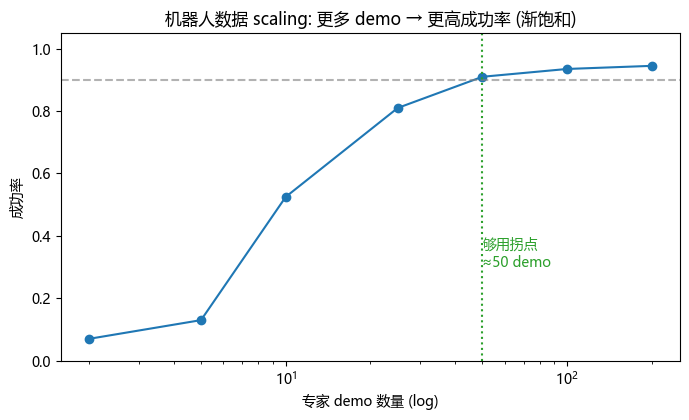

→ 少 demo 成功率低 (分布漂移); ~50 条后接近饱和。数据是机器人最大杠杆 (L3)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, ax = plt.subplots(figsize=(7,4.3))
ax.plot(sizes, srs, 'o-', color='C0')
ax.set_xscale('log'); ax.set_xlabel('专家 demo 数量 (log)'); ax.set_ylabel('成功率'); ax.set_ylim(0,1.05)
ax.axhline(0.9, ls='--', c='gray', alpha=0.6)
# 标注"够用"拐点 (首个 ≥0.9)
import numpy as np
knee = next((n for n,s in zip(sizes,srs) if s>=0.9), None)
if knee: ax.axvline(knee, ls=':', c='C2'); ax.text(knee, 0.3, f'够用拐点\n≈{knee} demo', color='C2')
ax.set_title('机器人数据 scaling: 更多 demo → 更高成功率 (渐饱和)')
plt.tight_layout(); plt.show()
print(f'→ 少 demo 成功率低 (分布漂移); ~{knee} 条后接近饱和。数据是机器人最大杠杆 (L3)。')

## 3. 解读 (接 9.4 实验设计)

In [4]:
print('''scaling 实验的干净做法 (接 9.4):
  - 固定: 模型大小、训练步数、评估集、种子 → 只变 demo 数量 (单变量)
  - 否则: 混入其它变量, 曲线不可信 (因果不干净)

读这条曲线 (接 LLM scaling 直觉):
  - 上升段: 数据是瓶颈, 加数据立竿见影
  - 饱和段: 数据够了, 瓶颈转移 (模型容量/任务难度/数据多样性)
  - "够用拐点": 工程上性价比最高的数据量 (再加收益递减)

机器人现状: 多数任务还在"上升段" (数据远不够) → 数据是最大机会 (L3)。''')

scaling 实验的干净做法 (接 9.4):
  - 固定: 模型大小、训练步数、评估集、种子 → 只变 demo 数量 (单变量)
  - 否则: 混入其它变量, 曲线不可信 (因果不干净)

读这条曲线 (接 LLM scaling 直觉):
  - 上升段: 数据是瓶颈, 加数据立竿见影
  - 饱和段: 数据够了, 瓶颈转移 (模型容量/任务难度/数据多样性)
  - "够用拐点": 工程上性价比最高的数据量 (再加收益递减)

机器人现状: 多数任务还在"上升段" (数据远不够) → 数据是最大机会 (L3)。


## 4. 反思 (11.4 收口)

你画了机器人的数据 scaling 曲线。带走:
- **数据量 → 成功率**: 上升渐饱和, 同 LLM scaling; 少数据→分布漂移→低成功率。
- **干净 scaling 实验** (接 9.4): 单变量 (只变数据量), 固定其它。
- **多样性 > 单纯量** (L3): toy 的随机起点/目标 = 天然多样, 故少量就泛化。
- 机器人现状多在「上升段」: 数据是最大瓶颈也是最大机会。

> **M11.4 收口**: BC 是训练基础 (分布漂移); 数据靠遥操作 (贵) + scaling + co-train + 人类视频。
> **交棒 M11.5「world-action-models」**: 从纯模仿到带想象 —— 具身世界模型, 接你 M13.5 的 `world_model.py`。下一专题 `world-action-models`。